In [1]:
import os
import sys
import argparse
from pathlib import Path
from time import sleep

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from itertools import combinations
from scipy import stats



In [2]:
# sns.set_theme() # applies seaborn style to all plots, different themes available
sns.set_style("whitegrid")#some global matplotlib options
plt.rcParams.update({
    "font.size":       14,   # base font size for text
    "axes.titlesize":  16,   #   … for axes titles
    "axes.labelsize":  14,   #   … for axis labels
    "xtick.labelsize": 12,   #   … for tick labels
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize":18,   #   … for suptitle
    "figure.dpi" :  110,

})

In [3]:
RESULTS_DIR   = Path("results")        # top-level output dir in layout_benchmark.py
METRIC_COLS   = ["solved", "time", "GCN", "LCN", "stress"]

DEFAULT_ALGOS = {
    "rlgc":    "RL(GC)",
    "rllc":    "RL(LC)",

    "smartgd": "SmartGD",
    "edgeins": "EI",
    "vermove": "VM",
    "fr":      "FR",
    "kk":      "KK",
    "sgd2":    "(SGD)²",
    # "ppo":     "PPO",
    "upwards": "TB",
}

ORDER = ['RL(GC)', 'RL(LC)', '(SGD)²', 'SmartGD', 'EI', 'VM', 'TB', 'KK', 'FR']

In [4]:


def read_and_relabel(csv_path: Path, algo_name: str) -> pd.DataFrame:
    """Load one csv and give its metric columns a MultiIndex (algo, metric)."""
    df = pd.read_csv(csv_path, sep=";", engine="python")  # adapt sep if needed
    if "instance" not in df.columns:
        raise ValueError(f"{csv_path} has no 'instance' column")
    df = df.set_index("instance")

    if not set(METRIC_COLS).issubset(df.columns):
        missing = set(METRIC_COLS) - set(df.columns)
        raise ValueError(f"{csv_path} missing columns: {missing}")

    # Select just the metrics we want
    df = df[METRIC_COLS]

    # Turn columns into a MultiIndex: 1st level = algo name, 2nd = metric
    df.columns = pd.MultiIndex.from_product([METRIC_COLS, [algo_name]])
    return df


def merge_algorithms(
    dataset_basename: str,
    algos: dict[str, str] | None = None,
    results_dir: Path | str = RESULTS_DIR,
    require_complete: bool = False,
) -> pd.DataFrame:
    """
    Parameters
    ----------
    dataset_basename : str
        File name without leading path, e.g. ``"benchmark_small.csv"``.
    algos : dict
        Mapping ``subfolder_name → label``.  None = DEFAULT_ALGOS.
    results_dir : Path | str
        Top-level directory that holds one subfolder per algorithm.
    """
    if algos is None:
        algos = DEFAULT_ALGOS

    pieces = []
    for folder, label in algos.items():
        csv_path = Path(results_dir) / folder / dataset_basename
        if not csv_path.exists():
            msg = f"[merge] {csv_path} not found"
            raise FileNotFoundError(msg)

        pieces.append(read_and_relabel(csv_path, label))

    if not pieces:
        raise RuntimeError("No input CSVs found – nothing to merge")

    merged = pd.concat(pieces, axis=1, join="outer")

    # reorder columns so they appear as  (metric1: A,B,C … , metric2: A,B,C …)
    new_order = []
    for metric in METRIC_COLS:
        # for _, label in algos.items():
        for label in ORDER:
            if (metric, label) in merged.columns:
                new_order.append((metric, label))
    # print(new_order)
    merged = merged.reindex(columns=pd.MultiIndex.from_tuples(new_order))

    if require_complete:
        before = len(merged)
        must_cols = [("solved", label) for label in ORDER if label in algos.values()]#, ("solved", "OLDRL")]
        solved_df = merged.loc[:, must_cols]

        # normalise to Python bool — covers {1, "True", "TRUE", "true", …}
        solved_bool = solved_df.map(lambda x: str(x).lower() in {"1", "true", "t", "yes", "1.0"})

        merged = merged[solved_bool.all(axis=1)]
        print(
            f"[merge] require_complete={require_complete} → "
            f"dropped {before - len(merged)} rows where some did *not* solve"
        )



    return merged

In [5]:
algos   = {
    "rlgc":    "RL(GC)",
    "rllc":    "RL(LC)",
    "smartgd": "SmartGD",
    "edgeins": "EI",
    "vermove": "VM",
    "fr":      "FR",
    "kk":      "KK",
    "sgd2":    "(SGD)²",
    # "ppo":     "PPO",
    "upwards": "TB",
    # "oldrl" :  "OLDRL",
}

dataset = "rome_filtered.csv"
merged_rome_df = merge_algorithms(dataset, algos, require_complete=False)
dataset = "extended_BA_filtered.csv"
merged_BA_df = merge_algorithms(dataset, algos, require_complete=False)

display(merged_rome_df.head())

solved                                         time  ... LCN  \
                 RL(GC) RL(LC) (SGD)² SmartGD EI VM TB KK FR  RL(GC)  ...  FR   
instance                                                              ...       
grafo5036.62.gml      1      1      1       1  1  1  1  1  1  3.8447  ...   5   
grafo5040.53.gml      1      1      1       1  1  1  1  1  1  2.7410  ...   5   
grafo5048.61.gml      1      1      1       1  1  1  1  1  1  2.6033  ...   4   
grafo5051.80.gml      1      1      1       1  1  1  1  1  1  3.1887  ...   6   
grafo5053.60.gml      1      1      1       1  1  1  1  1  1  4.0440  ...   6   

                  stress                                                  \
                  RL(GC)  RL(LC)  (SGD)² SmartGD      EI      VM      TB   
instance                                                                   
grafo5036.62.gml  0.3535  0.2979  0.3917  0.2953  0.5925  0.5370  0.3322   
grafo5040.53.gml  0.2687  0.3204  0.4218  0.2983  0.6445  0.5263  0.3524   
grafo5048.61.gml  0.3117  0.2310  0.3657  0.2298  0.5493  0.5202  0.3055   
grafo5051.80.gml  0.3443  0.3182  0.3881  0.3750  0.6202  0.5645  0.3482   
grafo5053.60.gml  0.4217  0.2976  0.4057  0.2837  0.5677  0.5912  0.3524   

                                  
                      KK      FR  
instance                          
grafo5036.62.gml  0.2534  0.3408  
grafo5040.53.gml  0.2271  0.2669  
grafo5048.61.gml  0.1861  0.3644  
grafo5051.80.gml  0.2987  0.3288  
grafo5053.60.gml  0.2650  0.2856  

[5 rows x 45 columns]

In [20]:
# Numeric summaries
def summary(df: pd.DataFrame, metric: str = "GCN") -> pd.DataFrame:
    """Mean / median / stdev for one metric across all instances."""
    stats_df = (
        df.xs(metric, level=0, axis=1)
          .agg(["mean", "median", "std", "min", "max"])
          .T.rename_axis("algo")
          .sort_values("mean")
    )
    return (
        stats_df)

def win_table(df: pd.DataFrame, metric: str = "GCN") -> pd.DataFrame:
    """
    For each pair (A,B) count on how many instances A's metric < B's.
    """
    metric_df = df.xs(metric, level=0, axis=1)
    wins = pd.DataFrame(0, index=ORDER, columns=ORDER, dtype=int)
    for a, b in combinations(ORDER, 2):
        sa = metric_df[a]
        sb = metric_df[b]

        # masks of who has numbers
        na = sa.notna()
        nb = sb.notna()

        # 1) both solved → compare numeric
        both = na & nb
        a_gt = (sa[both] < sb[both]).sum()
        b_gt = (sb[both] < sa[both]).sum()

        # 2) solved vs unsolved
        a_only = na & ~nb
        b_only = nb & ~na
        a_num = a_only.sum()   # A solved, B didn't → A wins
        b_num = b_only.sum()   # B solved, A didn't → B wins

        wins.loc[a, b] = a_gt + a_num
        wins.loc[b, a] = b_gt + b_num
    return wins

# display numeric overview
if True:
    df = merged_rome_df
    # df = merged_BA_df
    METRIC = "LCN"

    print(f"=== {METRIC} Crossing Number – summary ===")
    display(summary(df, METRIC))

    print(f"\n=== Pairwise wins (lower {METRIC}) ===")
    display(win_table(df, METRIC))


    print("=== Time – summary ===")
    display(summary(df, "time"))

=== LCN Crossing Number – summary ===


,mean,median,std,min,max
algo,,,,,
VM,2.965434,3.0,1.674522,1.0,10.0
RL(LC),3.087326,3.0,1.865538,1.0,13.0
EI,3.504854,3.0,2.106163,1.0,13.0
SmartGD,3.680412,3.0,2.013392,1.0,14.0
(SGD)²,3.996361,4.0,1.862699,1.0,15.0
RL(GC),4.002426,4.0,2.179448,1.0,12.0
TB,4.047301,4.0,2.115062,1.0,14.0
KK,4.081868,4.0,1.964791,1.0,15.0
FR,5.095816,5.0,2.465153,1.0,16.0



=== Pairwise wins (lower LCN) ===


,RL(GC),RL(LC),(SGD)²,SmartGD,EI,VM,TB,KK,FR
RL(GC),0,157,646,476,394,154,631,644,1092
RL(LC),928,0,1057,892,734,460,1099,1159,1421
(SGD)²,584,217,0,416,366,140,563,594,1016
SmartGD,670,257,734,0,460,199,715,765,1194
EI,734,326,829,636,0,256,838,886,1268
VM,938,456,1069,865,723,0,1111,1161,1455
TB,518,147,549,364,316,79,0,489,1038
KK,475,142,533,312,295,69,404,0,994
FR,252,76,262,155,107,24,215,203,0


=== Time – summary ===


,mean,median,std,min,max
algo,,,,,
FR,0.004881,0.0041,0.002605,0.0012,0.0129
TB,0.007725,0.0074,0.001830,0.0048,0.0214
KK,0.019895,0.0158,0.013038,0.0023,0.1011
SmartGD,0.176688,0.1696,0.030746,0.0532,0.3108
RL(LC),2.367328,2.7903,1.279019,0.0350,4.8848
RL(GC),3.018893,3.2929,1.381144,0.0323,5.5304
VM,15.310272,10.3910,14.347729,0.1976,85.8431
(SGD)²,47.888537,47.7232,3.018750,41.5668,76.5051
EI,59.046470,21.4463,87.589757,0.1922,900.0000


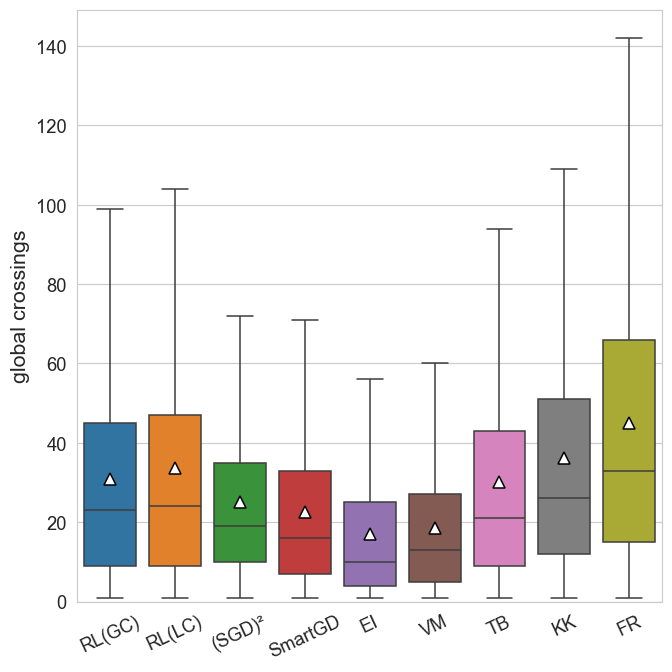

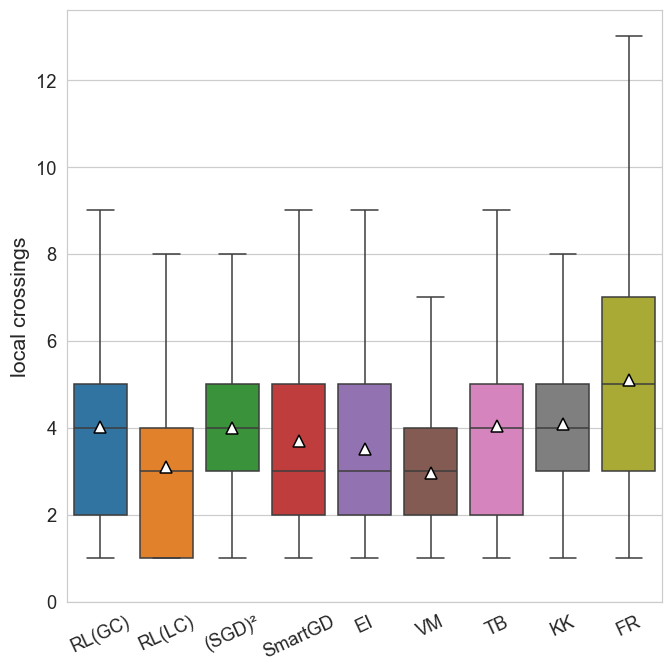

[merge] require_complete=True → dropped 409 rows where some did *not* solve


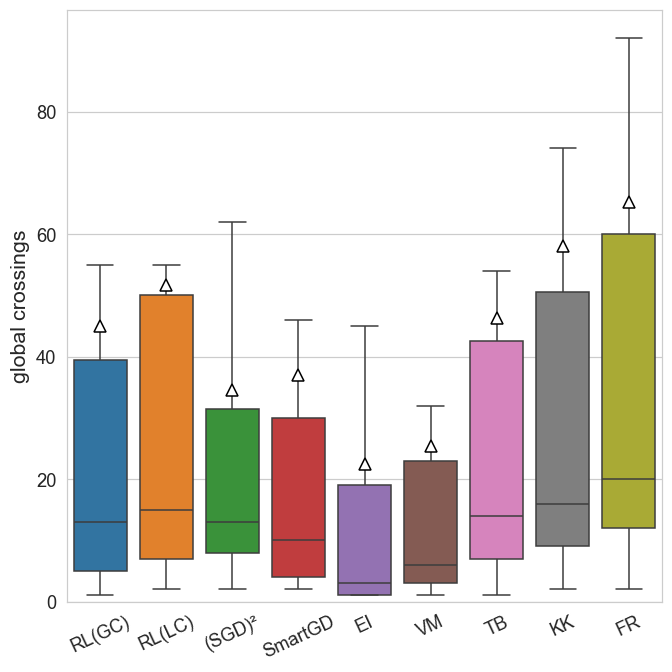

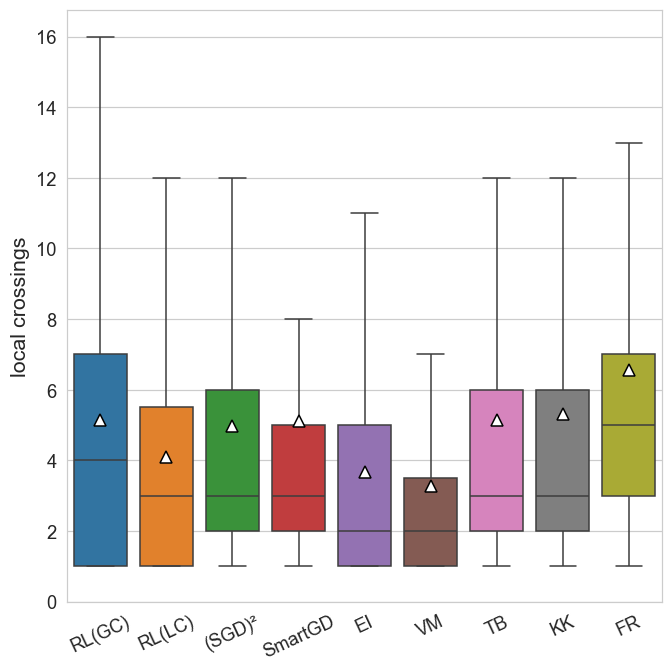

C:\Users\Timo\AppData\Local\Temp\ipykernel_23740\2704047876.py:13: UserWarning: The palette list has more values (9) than needed (7), which may not be intended.
  sns.boxplot(data=df, palette=pal, showfliers=False, showmeans=True,  meanprops={'marker':'^','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})


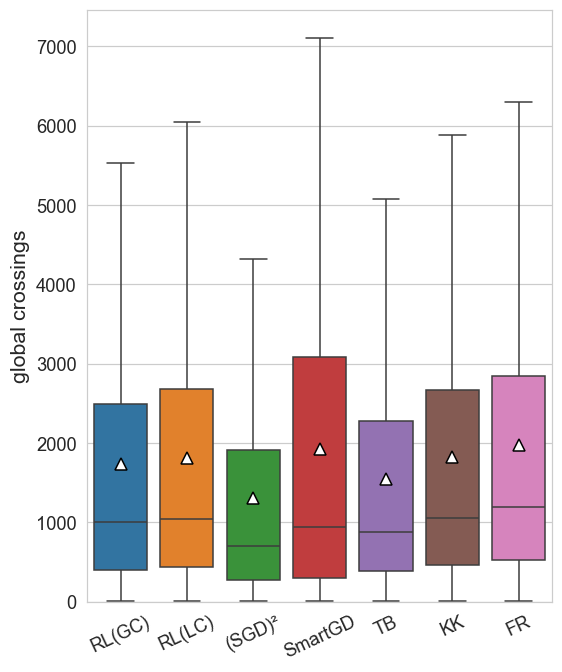

C:\Users\Timo\AppData\Local\Temp\ipykernel_23740\2704047876.py:13: UserWarning: The palette list has more values (9) than needed (7), which may not be intended.
  sns.boxplot(data=df, palette=pal, showfliers=False, showmeans=True,  meanprops={'marker':'^','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})


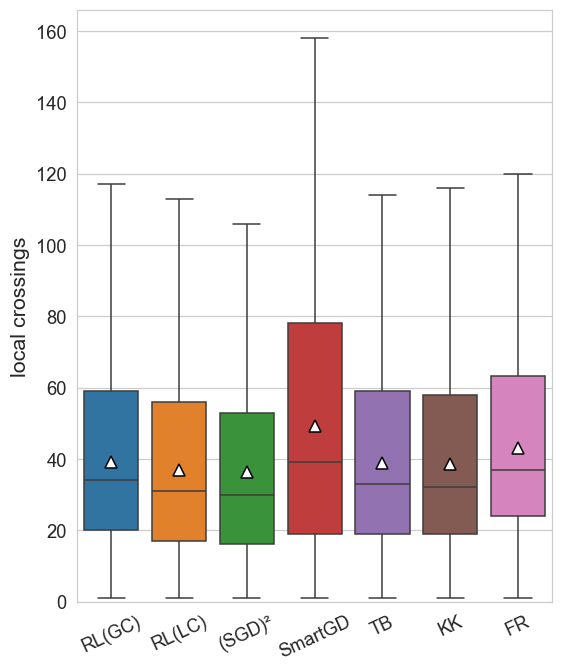

In [7]:
import copy
pd.DataFrame.iteritems = pd.DataFrame.items

# plots (column MI: level-0=algo, level-1=metric)
pal = sns.color_palette("tab10", len(ORDER))


# boxplot distribution of GCNs
def crossing_boxplot(df, metric="GCN", label="", figsize=(6,6)):
    plt.figure(figsize=figsize, constrained_layout=True)
    # merged_df = merged_df.sample(n=200, random_state=42)
    df = df.xs(metric, level=0, axis=1)
    sns.boxplot(data=df, palette=pal, showfliers=False, showmeans=True,  meanprops={'marker':'^','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})
    #sns.stripplot(data=df, palette=pal, jitter=0.25, size=4, alpha=0.25, dodge=False)
    # sns.swarmplot(data=df, palette=pal, size=1, alpha=0.75, dodge=False)
    # sns.violinplot(data=df, palette=pal, alpha=0.5, dodge=False, cut=0)
    # means = df.mean()
    # for i, m in enumerate(means):
    #     plt.scatter(i, m, marker="^", s=50, facecolor="white", edgecolor="black",zorder=10)

    plt.ylabel("global crossings" if metric == "GCN" else "local crossings")
    # plt.title(f"{metric} distribution")
    # plt.yscale("log")
    # plt.tight_layout()
    plt.xticks(rotation=25, ha='center')
    plt.ylim([0,None])
    plt.savefig(f"figures/boxplot_{metric}_{label}.pdf")
    # plt.savefig(f"figures/stripplot_{metric}_{label}.pdf")
    plt.show()


def boxplots(dataset):
    if "rome" in dataset:
        crossing_boxplot(merged_rome_df, label=dataset, metric="GCN")
        crossing_boxplot(merged_rome_df, label=dataset, metric="LCN")
    else:
        merged_BA_df = merge_algorithms("extended_BA_filtered.csv", require_complete=True)
        crossing_boxplot(merged_BA_df, metric="GCN", label="BA_restricted_solved")
        crossing_boxplot(merged_BA_df, metric="LCN", label="BA_restricted_solved")

        algo_copy = copy.deepcopy(algos); algo_copy.pop("edgeins"); algo_copy.pop("vermove")
        merged_BA_df = merge_algorithms("extended_BA_filtered.csv", algo_copy, require_complete=False)
        pal = sns.color_palette("tab10", len(ORDER))
        del pal[4]; del pal[4]
        crossing_boxplot(merged_BA_df, metric="GCN", label="BA_all_instances", figsize=(5,6))
        crossing_boxplot(merged_BA_df, metric="LCN", label="BA_all_instances", figsize=(5,6))
    pal = sns.color_palette("tab10", len(ORDER))


boxplots("rome")
boxplots("extended_BA")
pal = sns.color_palette("tab10", len(ORDER))



In [8]:
def plot_win_heatmap(df: pd.DataFrame,
                     label: str,
                     metric: str = "GCN",
                     algos: list[str] | None = None,
                     order_by_wins: bool = False,
                     custom_order: list[str] | None = None,
                     annot: bool = True,
                     cmap: str = "Blues"):
    """
    Draw a heatmap of pairwise wins (A beats B) for the given metric.

    - If order_by_wins=True, rows/cols are sorted by total wins descending.
    - If custom_order is a list of algos, that explicit order is used.
    - Otherwise uses the order in `algos` or all algos found.
    """
    # 1) determine algorithms to include
    if algos is None:
        algos = list(df.columns.levels[0])

    # 2) build the win‐counts DataFrame
    wins = win_table(df, metric).loc[algos, algos]
    wins = wins[algos]/len(df.index)

    # 3) choose the display order
    if custom_order:
        order = custom_order
    elif order_by_wins:
        # total wins = sum across each row
        order = wins.sum(axis=1).sort_values(ascending=False).index.tolist()
        order.remove("RL(GC)")
        order.remove("RL(LC)")
        order.insert(0, "RL(GC)")
        order.insert(1, "RL(LC)")

    else:
        order = algos

    # 4) re‐index rows & cols
    wins = wins.reindex(index=order, columns=order)


    # 5) plot
    plt.figure(figsize=(len(order), len(order)), constrained_layout=True)
    sns.heatmap(
        data=wins,
        annot=wins,
        fmt=".3f",
        cmap=cmap,
        cbar_kws={"label": f" #graphs where row beats col ({metric})"},
        vmin=0, vmax=1
    )
    # plt.title(f"Pairwise Win Matrix ({metric})")
    plt.ylabel("Winner")
    plt.xlabel("Loser")
    # plt.tight_layout()
    plt.savefig(f"figures/pairwise_{metric}_{label}.pdf")
    plt.show()




def heatmap(dataset):
    if "rome" in dataset:
        plot_win_heatmap(merged_rome_df, label="rome", metric="GCN", algos=ORDER, custom_order=ORDER)
        plot_win_heatmap(merged_rome_df, label="rome", metric="LCN", algos=ORDER)
    else:

        merged_BA_df = merge_algorithms("extended_BA_filtered.csv", algos, require_complete=False)
        plot_win_heatmap(merged_BA_df, label="BA", metric="GCN", algos=ORDER)
        plot_win_heatmap(merged_BA_df, label="BA", metric="LCN", algos=ORDER)


# heatmap("rome")
# heatmap("extended_BA")


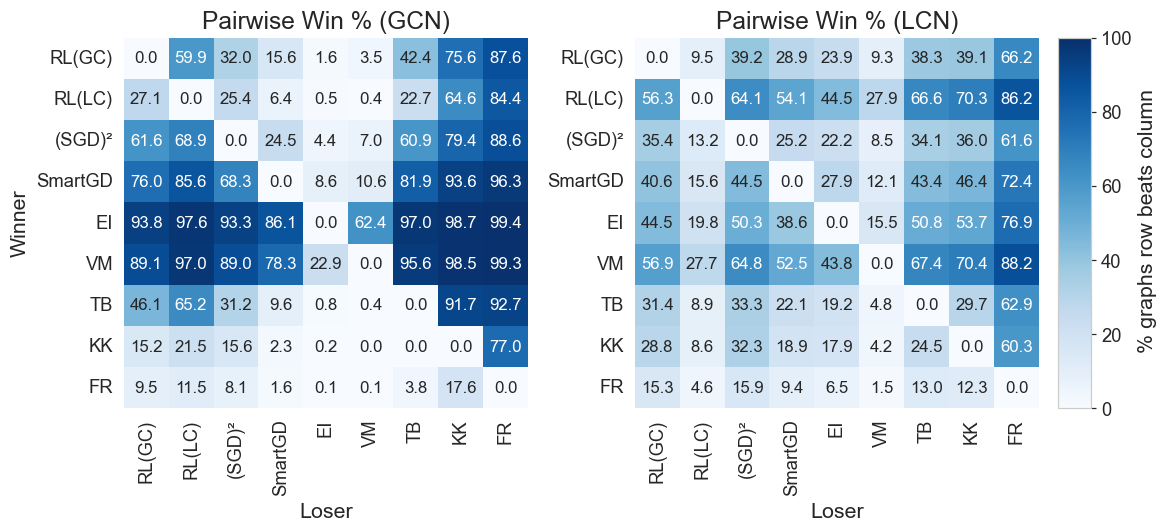

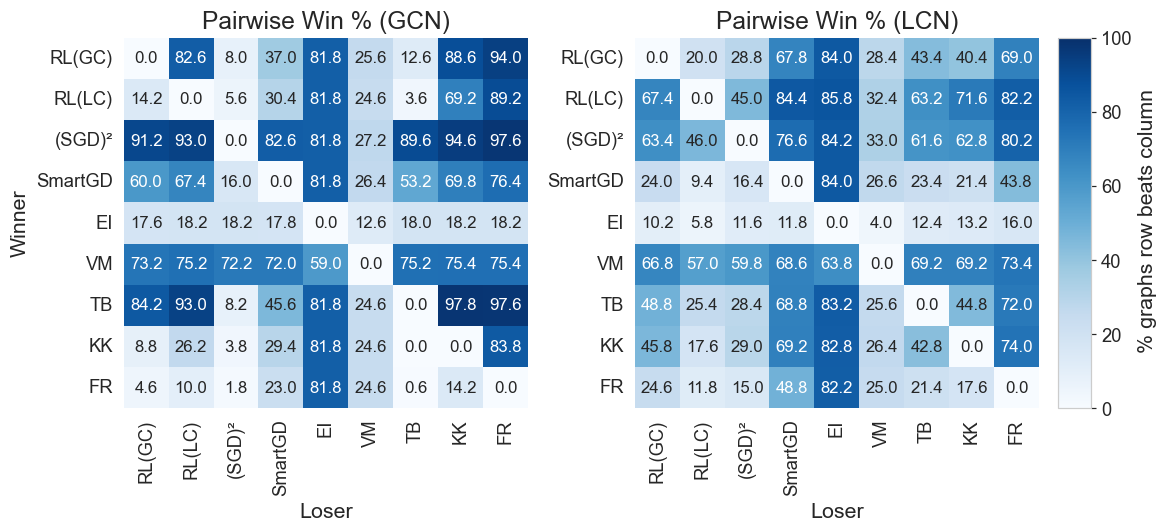

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_two_win_heatmaps(df: pd.DataFrame,
                          metrics: tuple[str,str] = ("GCN","LCN"),
                          algos: list[str] | None = None,
                          order_by_wins: bool = False,
                          custom_order: list[str] | None = None,
                          annot: bool = True,
                          cmap: str = "Blues",
                          name=""
                        ):
    """
    Plot two side-by-side heatmaps (for metrics[0] and metrics[1]) sharing
    a single colorbar on the right.
    """
    if algos is None:
        algos = list(df.columns.levels[0])

    # 1) build and normalize both win tables
    wins = {}
    n = len(df)
    for metric in metrics:
        w = win_table(df, metric).loc[algos, algos] *100 / n
        wins[metric] = w

    # 2) choose display order once (by first metric)
    if custom_order:
        order = custom_order
    elif order_by_wins:
        base = wins[metrics[0]]
        order = base.sum(axis=1).sort_values(ascending=False).index.tolist()
    else:
        order = algos

    # reindex both
    for metric in metrics:
        wins[metric] = wins[metric].reindex(index=order, columns=order)

    # 3) create figure with GridSpec: two subplots + one colorbar axis
    fig = plt.figure(figsize=(3.5*2*1.5, 2.1*0.25*len(order)), constrained_layout=True)  # width×2, height ~ rows×0.25
    gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.08], wspace=0.05)

    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]
    cax   = fig.add_subplot(gs[0,2])

    # 4) plot both heatmaps (no colorbar) and keep the last mappable
    mappable = None
    for ax, metric in zip(axes, metrics):
        mappable = sns.heatmap(
            wins[metric],
            ax=ax,
            annot=annot,
            fmt=".1f",
            cmap=cmap,
            vmin=0, vmax=100,
            cbar=False,
            annot_kws={"size": 11},
            # square=True
        )
        ax.set_title(f"Pairwise Win % ({metric})")
        if metric == "GCN":
            ax.set_ylabel("Winner")
        ax.set_xlabel("Loser")
        # ax.tick_params(axis='x',rotation=55)


    # 5) single shared colorbar
    fig.colorbar(
        mappable.get_children()[0],  # the QuadMesh
        cax=cax,
        orientation="vertical",
        label=" % graphs row beats column"
    )
    # plt.suptitle(f"Pairwise Win Percentages ({name})", y=1.02)
    # plt.tight_layout()
    plt.savefig(f"figures/pairwise_two_{name}.pdf", bbox_inches="tight")
    plt.show()


plot_two_win_heatmaps(
    merged_rome_df,
    metrics=("GCN","LCN"),
    algos=ORDER,
    name="Rome"
)
plot_two_win_heatmaps(
    merged_BA_df,
    metrics=("GCN","LCN"),
    algos=ORDER,
    name = "Barabási-Albert"
)



In [10]:
# # runtime & solved plots
# time_df   = merged_df.xs("time", axis=1, level=0)
# solved_df = merged_df.xs("solved", axis=1, level=0).fillna(0).astype(int)
# pal = sns.color_palette("tab10", len(ALGOS))
#
# solved_cnt = solved_df.sum()
# for x,y in zip(solved_cnt.index, solved_cnt.values):
#     print(x, "solved", y, "/", solved_df.shape[0], f"({y / solved_df.shape[0]*100}%)", end="   ")
# print(" ")
# # plt.figure(figsize=(6,6))
# # sns.barplot(x=solved_cnt.index, y=solved_cnt.values, palette=pal)
# # plt.ylabel("# graphs solved"); plt.title("Solved instances per algorithm")
# # plt.tight_layout(); plt.show()
#
# # 2️⃣  runtime bar with robust error bars (median ± IQR) -------------------
# median = time_df.median()
# iqr    = (time_df.quantile(0.75) - time_df.quantile(0.25)) / 2
# xpos   = np.arange(len(ALGOS))
#
# plt.figure(figsize=(6,6), constrained_layout=True)
# # sns.barplot(x=median.index, y=median.values, palette=pal, errorbar=None)
# # plt.errorbar(xpos, median.values, yerr=iqr.values,
# #              fmt='none', ecolor='black', elinewidth=1.1, capsize=4)
# sns.boxplot(data=time_df, palette=pal, showfliers=False, meanprops={'marker':'^','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})
# plt.ylabel("runtime [s]  (median ± IQR)")
# # plt.yscale("log")
# # plt.title("Algorithm speed")
# plt.xticks(rotation=25, ha='center')
# # plt.tight_layout()
# plt.savefig(f"figures/runningtime_boxplot_{dataset_name}.pdf")
# plt.show()
#
# # 3️⃣  ECDF of runtimes -----------------------------------------------------
# time_limit=900
# n_total = len(time_df)          # total number of instances
# plt.figure(figsize=(6, 6), constrained_layout=True)
# cnt = 0
# for alg, color in zip(ORDER, pal):
#     # 1) get only the solved times, sorted
#     solved = time_df[alg].where(solved_df[alg] == 1).dropna().sort_values().to_numpy()
#     m = len(solved)
#
#     if m == 0:
#         continue  # no solves at all
#
#     # 2) y-values = fraction of ALL instances
#     y = np.arange(1, m+1) / n_total
#
#     # 3) plot as a step (post so each jump happens *after* the time)
#     plt.step(solved, y, where="post", label=alg, color=pal[cnt], lw=1.5)
#     cnt += 1
#
#
#
# # finish styling
# plt.xscale("log")
# plt.xlim(left=1e-2, right=time_limit*2)  # a bit of padding
# plt.ylim(0, 1.0)
# plt.xlabel("runtime [s]")
# plt.ylabel(f"fraction solved ≤ t")
# # plt.title("Survival curves: runtime-to-solve")
# plt.legend()
# # plt.legend(loc='lower right', bbox_to_anchor=(1.015, -0.015))
# # plt.tight_layout()
# plt.savefig(f"figures/runningtime_survival_{dataset_name}.pdf")
# plt.show()
# # plt.figure(figsize=(12,6))
# # for a,c in zip(ALGOS, pal):
# #     sns.ecdfplot(time_df[a], label=a, lw=1.5, color=c)
# # plt.xlabel("runtime [s]"); plt.ylabel("fraction solved ≤ t")
# # plt.title("Empirical CDF of runtime"); plt.legend(); plt.tight_layout()
# # plt.xscale("log")
# # plt.savefig(f"figures/runningtime_survival_{dataset_name}.pdf")
# # plt.show()
#


C:\Users\Timo\AppData\Local\Temp\ipykernel_23740\2147879839.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(ORDER, rotation=45, ha='center')


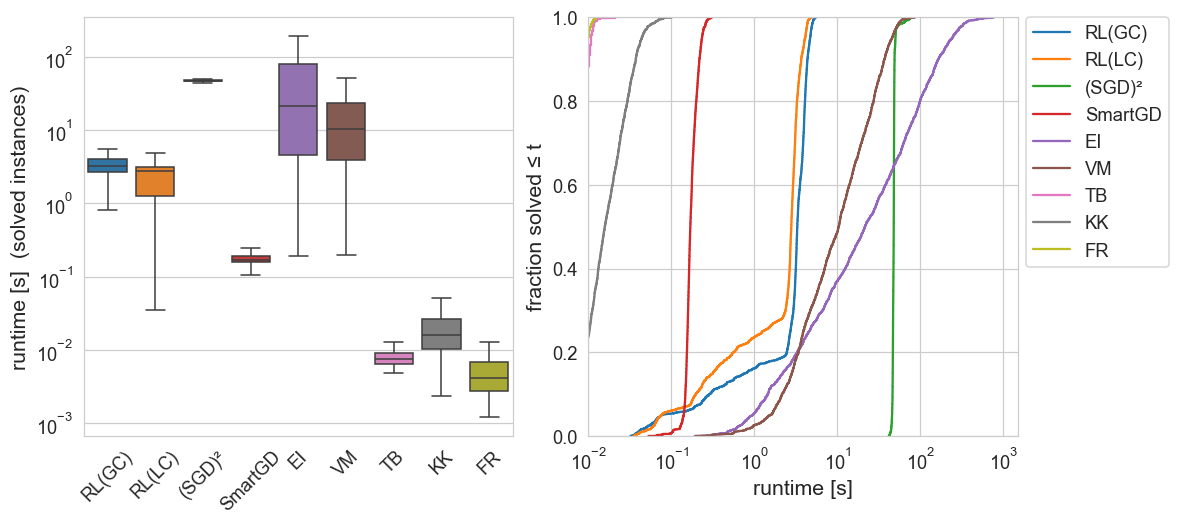

C:\Users\Timo\AppData\Local\Temp\ipykernel_23740\2147879839.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(ORDER, rotation=45, ha='center')


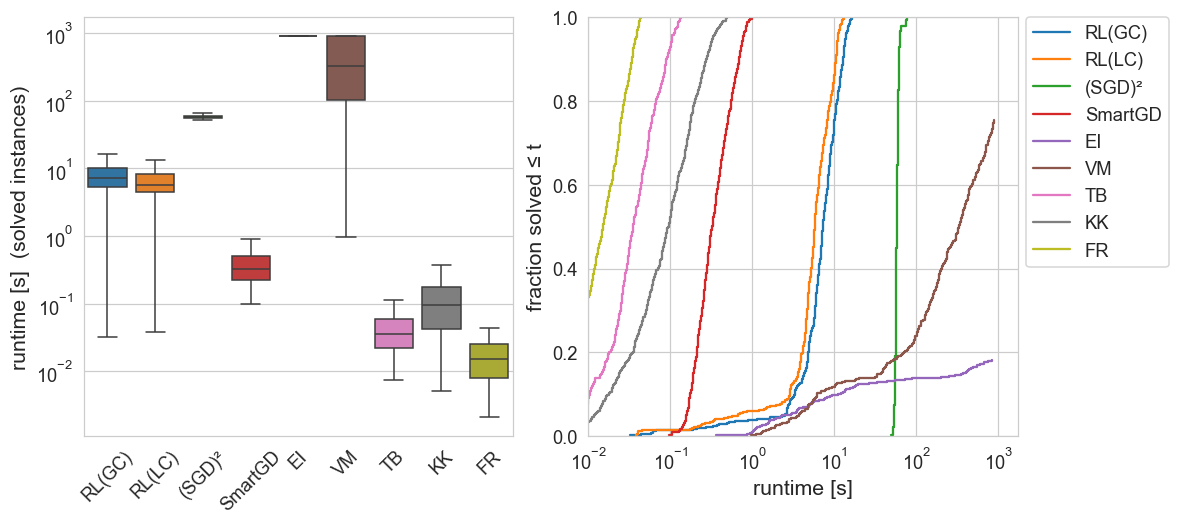

In [11]:
def plot_runtime_and_ecdf(df: pd.DataFrame,
                          name: str,
                          ORDER: list[str],
                          pal: list[str],
                          time_limit: float = 900):
    """
    Plots two subplots side by side:
     - Left: runtime boxplot (distribution of runtimes for solved instances, per algorithm)
     - Right: ECDF / survival plot of runtime (fraction solved ≤ t) vs t, log-scale x-axis,
       with legend placed outside to the right.
    """

    time_df   = df.xs("time", axis=1, level=0)
    solved_df = df.xs("solved", axis=1, level=0).fillna(0).astype(int)

    n_total = len(time_df)

    # Create the figure with 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=False)
    ax_box, ax_ecdf = axes

    ##### Left subplot: runtime boxplot #####
    sns.boxplot(data=time_df[ORDER], palette=pal, showfliers=False, ax=ax_box,
                meanprops={'marker':'^','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})
    ax_box.set_ylabel("runtime [s]  (solved instances)")
    ax_box.set_xlabel("")  # no x-label or you can label "Algorithm"
    ax_box.set_xticklabels(ORDER, rotation=45, ha='center')
    # ax_box.set_title("Runtime distribution", fontsize=14)
    # If you want log-scale on y for boxplot:
    ax_box.set_yscale("log")

    ##### Right subplot: ECDF / survival plot #####
    for alg, color in zip(ORDER, pal):
        # get solved runtimes sorted
        mask = (solved_df[alg] == 1)
        solved = time_df[alg].where(mask).dropna().sort_values().to_numpy()
        m = len(solved)
        if m == 0:
            # no solves, skip plotting this algorithm
            continue
        # y-values: fraction of ALL instances ≤ t
        y = np.arange(1, m+1) / n_total
        # step plot: where='post' so that step jumps after the x-value
        ax_ecdf.step(solved, y, where="post", label=alg, color=color, lw=1.5)

    ax_ecdf.set_xscale("log")
    ax_ecdf.set_xlim(left=1e-2)#, right=time_limit * 1.1)  # left padding to avoid zero; adjust as needed
    ax_ecdf.set_ylim(0, 1.0)
    ax_ecdf.set_xlabel("runtime [s]")
    ax_ecdf.set_ylabel("fraction solved ≤ t")
    # ax_ecdf.set_title("Survival curve of runtime", fontsize=14)

    # Place legend to the right outside the plot
    # bbox_to_anchor: (x0, y0): top-left corner of legend bbox in axes coordinates.
    # loc='upper left' means legend's upper-left corner is at bbox_to_anchor.
    ax_ecdf.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    # Optionally: adjust the axes to make room for legend
    # We'll call subplots_adjust after tight_layout.

    # 3) Final layout adjustments
    # Use tight_layout first:
    plt.tight_layout()
    # Then make room on the right for the legend:
    plt.subplots_adjust(right=0.78)  # shrink right side so that legend (outside at ~0.82) fits
    # You may tweak `right` fraction as needed: smaller -> more room.


    # Save or show
    plt.savefig(f"figures/runningtime_comparison_{name}.pdf", bbox_inches='tight')
    plt.show()

    return fig, (ax_box, ax_ecdf)


# Example usage:
fig, (axb, axe) = plot_runtime_and_ecdf(merged_rome_df, "rome", ORDER, pal, time_limit=900)
fig, (axb, axe) = plot_runtime_and_ecdf(merged_BA_df, "BA", ORDER, pal, time_limit=900)

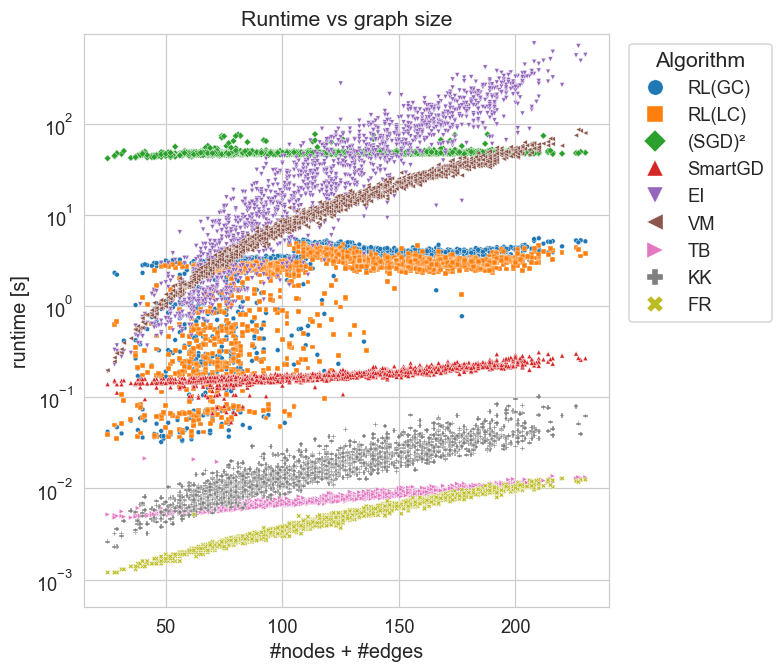

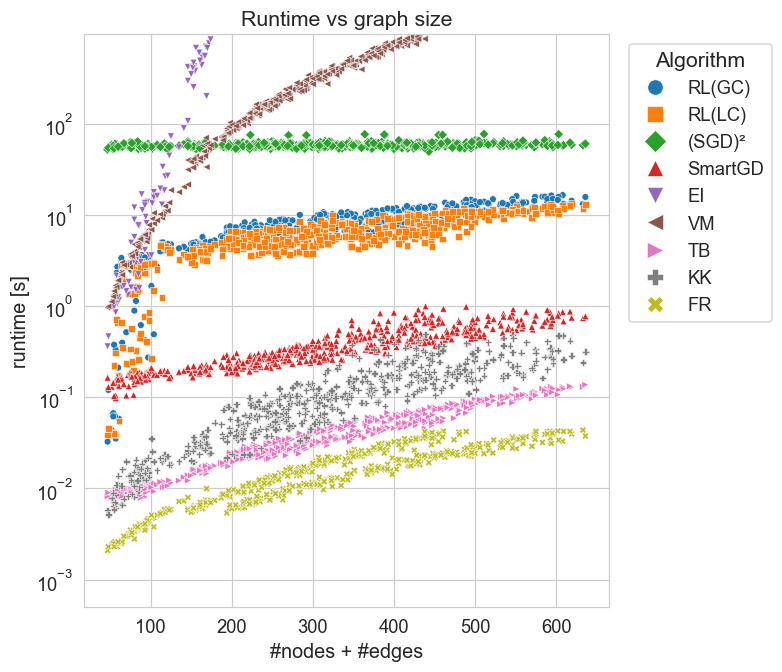

In [12]:
import os
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MARKERS = [
    "o",   # circle
    "s",   # square
    "D",   # diamond
    "^",   # upward triangle
    "v",   # downward triangle
    "<",   # left triangle
    ">",   # right triangle
    "P",   # plus (filled)
    "X",   # X (filled)
    "*",   # star (use sparingly, bold!)
]

def add_graph_size_columns(df, root, instance_col=None):
    def load_graph(path_no_root):
        path = root+"/"+path_no_root
        # choose reader from extension; fall back sensibly
        ext = os.path.splitext(path)[1].lower()
        if ext == ".gml":
            G = nx.read_gml(path)
        elif ext in (".gexf",):
            G = nx.read_gexf(path)
        elif ext in (".graphml",):
            G = nx.read_graphml(path)
        else:
            # try common formats
            try:
                G = nx.read_gexf(path)
            except Exception:
                G = nx.read_gml(path)
        # work on simple undirected graphs
        if G.is_multigraph():
            G = nx.Graph(G)
        if G.is_directed():
            G = G.to_undirected()
        # optional: relabel to 0..N-1
        G = nx.convert_node_labels_to_integers(G)
        return G

    instances = df[instance_col].values if (instance_col is not None and instance_col in df.columns) else df.index

    num_nodes, num_edges = [], []
    for inst in instances:
        G = load_graph(inst)
        num_nodes.append(G.number_of_nodes())
        num_edges.append(G.number_of_edges())

    df_out = df.copy()
    df_out["num_nodes"] = num_nodes
    df_out["num_edges"] = num_edges
    df_out["size"] = df_out["num_nodes"] + df_out["num_edges"]
    return df_out


def runtime_vs_size(df_with_size, algos=None, palette=None, dataset_name="", savepath=None, ylog=True):
    if isinstance(df_with_size.columns, pd.MultiIndex):
        time_df = df_with_size.xs("time", axis=1, level=0)
    else:
        time_df = df_with_size[algos] if algos is not None else df_with_size.select_dtypes(include=[np.number])

    solved_df = df_with_size.xs("solved", axis=1, level=0).fillna(0).astype(int)
    time_df = time_df.where(solved_df == 1)

    # 2) melt while KEEPING 'size'
    long_df = (
        time_df
        .assign(size=df_with_size["size"].values)
        .melt(id_vars=["size"], var_name="algo", value_name="runtime")
        .dropna(subset=["runtime"])
    )

    markers = {alg: MARKERS[i % len(MARKERS)] for i, alg in enumerate(long_df["algo"].unique())}
    palette = {alg: palette[i % len(algos)] for i,alg in enumerate(long_df["algo"].unique())}


    # 3) plot
    plt.figure(figsize=(7, 6), constrained_layout=True)
    sns.scatterplot(
        data=long_df, x="size", y="runtime",
        hue="algo", hue_order=ORDER, palette=palette,
        alpha=1.0, s=10 if "rom" in  dataset_name else 20,
        markers=markers,style="algo",
    )
    plt.ylim(bottom=0.0005, top=950)
    if ylog:
        plt.yscale("log")
    plt.xlabel("#nodes + #edges", fontsize=13)
    plt.ylabel("runtime [s]", fontsize=13)
    plt.title(f"Runtime vs graph size", fontsize=14)
    lgnd = plt.legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")
    for handle in lgnd.legend_handles:
        handle.set_markersize(10)
    if savepath:
        plt.savefig(savepath)
    plt.show()



def runtimesize(dataset):
    pal = sns.color_palette("tab10", len(ORDER))
    order_copy = copy.deepcopy(algos)
    if dataset == "rome":
        root = "graphs/rome_filtered/splits/data"
        df = merged_rome_df
    else:
        root = "graphs/extended_BA_filtered/data"
        # order_copy.pop("edgeins"); order_copy.pop("vermove")
        df = merge_algorithms("extended_BA_filtered.csv", order_copy, require_complete=False)
        # del pal[4]; del pal[4]
        # del MARKERS[4]; del MARKERS[4]



    # add sizes (use your root)
    extended_df = add_graph_size_columns(
        df,
        root=root,
        instance_col=None   # your instance key is in the index; set to "instance" if it’s a column
    )

    # make the plot
    runtime_vs_size(
        df_with_size=extended_df,
        algos=order_copy,            # or list(extended_df.xs("time", axis=1, level=0).columns)
        palette=pal,
        dataset_name=dataset,
        savepath=f"figures/runtime_vs_size_{dataset}.pdf",
    )

runtimesize("rome")
runtimesize("Extended_BA")


In [16]:
merged_df_rome = merge_algorithms("rome_filtered.csv", algos, require_complete=False)
merged_df_ba = merge_algorithms("extended_BA_filtered.csv", algos, require_complete=True)
merged_df = merged_df_rome
import pandas as pd
import numpy as np
from scipy import stats
import scikit_posthocs as sp
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Example: merged_df is your MultiIndex DataFrame
# Columns: level0 = algorithm names, level1 = metrics ("GCN", "LCN", "time", etc.)
# List of algorithms in consideration:
ALGOS = ORDER  # or specify subset

# Extract the global crossing numbers into a DataFrame: rows=instances, cols=algorithms
def get_metric_df(merged_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Returns a DataFrame of shape (n_instances, n_algorithms) for the given metric.
    Values may be NaN if an algorithm failed on an instance.
    """
    # .xs returns columns for that metric
    metric_df = merged_df.xs(metric, level=0, axis=1)  # level=1 for metric
    # Sometimes level ordering swapped; if your metric is level 0, adjust to level=0
    # metric_df = merged_df.xs(metric, level=0, axis=1)
    return metric_df

# gcn_df = get_metric_df(merged_df_rome, "GCN")
gcn_df = get_metric_df(merged_df, "GCN")
# Optionally drop instances where all algorithms failed (all NaN), or handle per test
print("Shape of GCN DataFrame:", gcn_df.shape)


# Summary statistics:
desc = gcn_df.describe().T  # includes count, mean, std, min, quartiles, max
desc["median"] = gcn_df.median()
desc["IQR"] = gcn_df.quantile(0.75) - gcn_df.quantile(0.25)
display(desc[["count","median","IQR","mean","std","min","max"]])



# Friedman requires no missing data: only include instances where all algorithms have a value.
# Alternatively, you can do Friedman on the subset of instances where no NaN for any of the selected algos.
algos2 = ALGOS  # or a subset, e.g., ["SmartGD","EI","FR",...]
# Subset columns:
df_sub = gcn_df[algos2]

# Drop rows with any NaN:
df_friedman = df_sub.dropna(axis=0, how='any')
print(f"Using {len(df_friedman)} instances (complete cases) for Friedman test.")

# Prepare data in the form of one array per algorithm:
arrays = [df_friedman[algo].values for algo in algos2]

# Run Friedman
stat, p = stats.friedmanchisquare(*arrays)
print(f"Friedman test statistic = {stat:.4f}, p-value = {p:.4g}")
if p < 0.05:
    print("→ Significant differences among algorithms (reject null of equal distributions).")
else:
    print("→ No significant difference detected among algorithms.")

from itertools import combinations
import statsmodels.stats.multitest as multitest

def pairwise_wilcoxon(gcn_df: pd.DataFrame, algos2: list[str], alpha=0.05, correction="bonferroni"):
    """
    Performs Wilcoxon signed-rank tests for all pairs of algorithms on GCN.
    Returns a DataFrame of p-values and adjusted p-values, plus effect sizes.
    """
    pairs = list(combinations(algos2, 2))
    pvals = []
    names = []
    for a, b in pairs:
        # select instances where both have non-NaN
        df_pair = gcn_df[[a, b]].dropna(axis=0, how='any')
        if df_pair.empty:
            p = np.nan
            stat = np.nan
            effect = np.nan
        else:
            # Wilcoxon: test whether median difference is zero
            # If many exact ties or zero differences, it may warn; consider zero_method='wilcox'
            try:
                stat, p = stats.wilcoxon(df_pair[a], df_pair[b], alternative='two-sided', zero_method='wilcox')
            except ValueError as e:
                # If data are identical or too few non-zero differences, stat test may fail:
                stat, p = np.nan, np.nan
            # Effect size: rank-biserial correlation = 1 - (2*W)/(n*(n+1)/2), but need W from test:
            # SciPy's wilcoxon returns W as 'stat'. For two-sided test:
            # For rank-biserial: r = 1 - 2*W/(n*(n+1)/2), see:
            n = len(df_pair)
            # Max W = n*(n+1)/2 for all positive differences; min W = 0 if all negative differences.
            if not np.isnan(stat):
                W = stat
                # rank-biserial r:
                r = 1 - 2*W/(n*(n+1)/2)
                effect = r
            else:
                effect = np.nan
        pvals.append(p)
        names.append((a, b, stat, effect))
    # Adjust p-values:
    pvals_clean = np.array([pv if not np.isnan(pv) else 1.0 for pv in pvals])
    reject, pvals_adj, _, _ = multitest.multipletests(pvals_clean, alpha=alpha, method=correction)
    # Build result DataFrame:
    results = []
    for (a, b, stat, effect), p_raw, p_adj, rej in zip(names, pvals, pvals_adj, reject):
        results.append({
            "algo_A": a,
            "algo_B": b,
            "W_stat": stat,
            "p_raw": p_raw,
            "p_adj": p_adj,
            "reject_null": rej,
            "effect_rank_biserial": effect
        })
    res_df = pd.DataFrame(results)
    return res_df

wilcox_results = pairwise_wilcoxon(gcn_df, algos2, alpha=0.05, correction="holm")
display(wilcox_results)

# scikit-posthocs expects a 2D array: shape (n_instances, n_algorithms)
# Using only complete cases (drop rows with any NaN among chosen algos2):
df_nemenyi = df_friedman  # from above: complete-case df for Friedman
# Convert to numpy:
data = df_nemenyi[algos2].values
# Run Nemenyi post-hoc:
nemenyi_results = sp.posthoc_nemenyi_friedman(data)
# The result is a DataFrame with p-values for each pair; index/columns correspond to columns order in data, i.e. algos2 order.
nemenyi_results.index = algos2
nemenyi_results.columns = algos2
print("Nemenyi post-hoc p-values:")
display(nemenyi_results)


import random

def bootstrap_median_ci(series: pd.Series, n_bootstrap=1000, ci=0.95, random_state=None):
    """
    Returns (median, lower_ci, upper_ci) for the given series via bootstrap.
    """
    rng = np.random.default_rng(random_state)
    arr = series.dropna().values
    n = len(arr)
    if n == 0:
        return (np.nan, np.nan, np.nan)
    medians = []
    for _ in range(n_bootstrap):
        sample = rng.choice(arr, size=n, replace=True)
        medians.append(np.median(sample))
    medians = np.array(medians)
    lower = np.percentile(medians, (1 - ci) / 2 * 100)
    upper = np.percentile(medians, (1 + ci) / 2 * 100)
    return np.median(arr), lower, upper

# Example usage:
ci_dict = {}
for algo in algos2:
    median, lo, hi = bootstrap_median_ci(gcn_df[algo], n_bootstrap=2000, ci=0.95, random_state=42)
    ci_dict[algo] = {"median": median, "ci_lower": lo, "ci_upper": hi}
ci_df = pd.DataFrame(ci_dict).T
display(ci_df)


def run_friedman_and_posthoc(merged_df: pd.DataFrame, metric: str, algos2: list[str]):
    """
    Runs Friedman test (on complete cases) for given metric, then Nemenyi post-hoc.
    Returns: dict with keys 'friedman_stat', 'friedman_p', 'nemenyi_pvals' (DataFrame).
    """
    metric_df = get_metric_df(merged_df, metric)
    df_sub = metric_df[algos2]
    df_complete = df_sub.dropna(axis=0, how='any')
    print(f"Friedman on {len(df_complete)} complete instances out of {len(df_sub)}.")

    if len(df_complete) < 2:
        print("Not enough data for Friedman.")
        return None

    arrays = [df_complete[a].values for a in algos2]
    stat, p = stats.friedmanchisquare(*arrays)
    print(f"Friedman: chi2={stat:.3f}, p={p:.4g}")
    res = {"friedman_stat": stat, "friedman_p": p}

    if p < 0.05:
        # Nemenyi
        try:
            import scikit_posthocs as sp
            data = df_complete[algos2].values
            pvals = sp.posthoc_nemenyi_friedman(data)
            pvals.index = algos2
            pvals.columns = algos2
            res["nemenyi_pvals"] = pvals
        except ImportError:
            print("scikit-posthocs not installed; skipping Nemenyi post-hoc.")
            res["nemenyi_pvals"] = None
    else:
        print("No significant difference; skipping post-hoc.")
        res["nemenyi_pvals"] = None

    return res

def run_pairwise_wilcoxon(merged_df: pd.DataFrame, metric: str, algos2: list[str], alpha=0.05):
    metric_df = get_metric_df(merged_df, metric)
    return pairwise_wilcoxon(metric_df, algos2, alpha=alpha, correction="holm")

algos2 = ALGOS  # your list in desired order
res = run_friedman_and_posthoc(merged_df, "GCN", algos2)
if res and res["nemenyi_pvals"] is not None:
    display(res["nemenyi_pvals"])

wilcox_df = run_pairwise_wilcoxon(merged_df, "GCN", algos2)
display(wilcox_df)

# 5. Effect size summary (from wilcox_df):
eff = wilcox_df.set_index(["algo_A","algo_B"])["effect_rank_biserial"]
print("Rank-biserial effect sizes:")
display(eff.unstack())



[merge] require_complete=True → dropped 409 rows where some did *not* solve
Shape of GCN DataFrame: (1649, 9)


,count,median,IQR,mean,std,min,max
RL(GC),1649.0,23.0,36.0,30.988478,28.270868,1.0,205.0
RL(LC),1649.0,24.0,38.0,33.617950,30.571075,1.0,212.0
(SGD)²,1649.0,19.0,25.0,25.135233,19.894638,1.0,130.0
SmartGD,1649.0,16.0,26.0,22.493633,20.090242,1.0,137.0
EI,1648.0,10.0,21.0,16.949636,17.805480,1.0,113.0
VM,1649.0,13.0,22.0,18.521528,17.621415,1.0,113.0
TB,1649.0,21.0,34.0,30.105518,27.171757,1.0,184.0
KK,1649.0,26.0,39.0,36.102486,31.558945,1.0,217.0
FR,1649.0,33.0,51.0,45.066101,38.782407,1.0,233.0


Using 1648 instances (complete cases) for Friedman test.
Friedman test statistic = 9534.4022, p-value = 0
→ Significant differences among algorithms (reject null of equal distributions).


,algo_A,algo_B,W_stat,p_raw,p_adj,reject_null,effect_rank_biserial
0,RL(GC),RL(LC),292213.5,7.098138e-46,1.419628e-45,True,0.570409
1,RL(GC),(SGD)²,268748.5,1.098984e-77,7.692885e-77,True,0.604905
2,RL(GC),SmartGD,76754.0,5.649941e-187,7.344923e-186,True,0.887162
3,RL(GC),EI,3587.5,9.412656e-256,2.447291e-254,True,0.994720
4,RL(GC),VM,8221.5,1.880541e-244,4.137190e-243,True,0.987913
5,RL(GC),TB,459288.0,4.216305e-06,4.216305e-06,True,0.324787
6,RL(GC),KK,132897.5,3.037246e-144,3.037246e-143,True,0.804624
7,RL(GC),FR,53211.5,6.258867e-222,1.126596e-220,True,0.921772
8,RL(LC),(SGD)²,182629.5,8.374607e-126,7.537147e-125,True,0.731511
9,RL(LC),SmartGD,21483.5,1.437282e-231,2.730837e-230,True,0.968416


Nemenyi post-hoc p-values:


...

Friedman on 1648 complete instances out of 1649.
Friedman: chi2=9534.402, p=0


,RL(GC),RL(LC),(SGD)²,SmartGD,EI,VM,TB,KK,FR
RL(GC),1.000000e+00,0.0,1.133703e-10,0.0,0.000000,0.000000,0.707562,0.0,0.0
RL(LC),0.000000e+00,1.0,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.0,0.0
(SGD)²,1.133703e-10,0.0,1.000000e+00,0.0,0.000000,0.000000,0.000007,0.0,0.0
SmartGD,0.000000e+00,0.0,0.000000e+00,1.0,0.000000,0.000000,0.000000,0.0,0.0
EI,0.000000e+00,0.0,0.000000e+00,0.0,1.000000,0.000001,0.000000,0.0,0.0
VM,0.000000e+00,0.0,0.000000e+00,0.0,0.000001,1.000000,0.000000,0.0,0.0
TB,7.075623e-01,0.0,6.744263e-06,0.0,0.000000,0.000000,1.000000,0.0,0.0
KK,0.000000e+00,0.0,0.000000e+00,0.0,0.000000,0.000000,0.000000,1.0,0.0
FR,0.000000e+00,0.0,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.0,1.0


,algo_A,algo_B,W_stat,p_raw,p_adj,reject_null,effect_rank_biserial
0,RL(GC),RL(LC),292213.5,7.098138e-46,1.419628e-45,True,0.570409
1,RL(GC),(SGD)²,268748.5,1.098984e-77,7.692885e-77,True,0.604905
2,RL(GC),SmartGD,76754.0,5.649941e-187,7.344923e-186,True,0.887162
3,RL(GC),EI,3587.5,9.412656e-256,2.447291e-254,True,0.994720
4,RL(GC),VM,8221.5,1.880541e-244,4.137190e-243,True,0.987913
5,RL(GC),TB,459288.0,4.216305e-06,4.216305e-06,True,0.324787
6,RL(GC),KK,132897.5,3.037246e-144,3.037246e-143,True,0.804624
7,RL(GC),FR,53211.5,6.258867e-222,1.126596e-220,True,0.921772
8,RL(LC),(SGD)²,182629.5,8.374607e-126,7.537147e-125,True,0.731511
9,RL(LC),SmartGD,21483.5,1.437282e-231,2.730837e-230,True,0.968416


Rank-biserial effect sizes:


algo_B,(SGD)²,EI,FR,KK,RL(LC),SmartGD,TB,VM
algo_A,,,,,,,,
(SGD)²,NaN,0.962710,0.956807,0.868877,NaN,0.607601,0.607549,0.948609
EI,NaN,NaN,1.000000,0.999090,NaN,NaN,0.996182,0.618780
KK,NaN,NaN,0.805004,NaN,NaN,NaN,NaN,NaN
RL(GC),0.604905,0.994720,0.921772,0.804624,0.570409,0.887162,0.324787,0.987913
RL(LC),0.731511,0.997698,0.869563,0.668876,NaN,0.968416,0.732281,0.999375
SmartGD,NaN,0.900283,0.996511,0.993931,NaN,NaN,0.935835,0.881611
TB,NaN,NaN,0.980622,1.000000,NaN,NaN,NaN,NaN
VM,NaN,NaN,0.999922,1.000000,NaN,NaN,0.999555,NaN


In [19]:
import pandas as pd
import numpy as np

def merge_upper_lower(pvals_rome: pd.DataFrame,
                      pvals_ba:   pd.DataFrame,
                      algos2:     list[str]) -> pd.DataFrame:
    """
    Given two symmetric DataFrames pvals_rome and pvals_ba (shape n_algos × n_algos,
    indexed and columned by the same algos2 list), produce a combined DataFrame of the
    same shape where:
      - combined.loc[A, B] = pvals_rome.loc[A, B]  if A != B and A < B in ordering
      - combined.loc[A, B] = pvals_ba.loc[A, B]    if A != B and A > B in ordering
      - combined.loc[A, A] = NaN
    Here “A < B in ordering” means according to the index order in algos2.
    We assume pvals_rome and pvals_ba may contain NaN where data was missing.
    """
    # Initialize empty DataFrame
    combined = pd.DataFrame(data=np.nan, index=algos2, columns=algos2, dtype=float)

    # For each pair (i, j) with i != j:
    for i, a in enumerate(algos2):
        for j, b in enumerate(algos2):
            if i == j:
                combined.at[a, b] = np.nan
            elif i < j:
                # above diagonal: use Rome
                # guard in case pvals_rome is missing a or b → remains NaN
                if a in pvals_rome.index and b in pvals_rome.columns:
                    combined.at[a, b] = pvals_rome.at[a, b]
                else:
                    combined.at[a, b] = np.nan
            else:  # i > j: below diagonal: use BA
                if a in pvals_ba.index and b in pvals_ba.columns:
                    combined.at[a, b] = pvals_ba.at[a, b]
                else:
                    combined.at[a, b] = np.nan
    return combined


merged_df_rome = merge_algorithms("rome_filtered.csv", algos, require_complete=False)
merged_df_ba   = merge_algorithms("extended_BA_filtered.csv", algos, require_complete=True)

# 3) Extract metric DataFrames
gcn_rome = get_metric_df(merged_df_rome, "GCN")
gcn_ba   = get_metric_df(merged_df_ba,   "GCN")

# 4) Run pairwise Wilcoxon for each dataset
wilcox_rome = pairwise_wilcoxon(gcn_rome, algos2, alpha=0.05, correction="holm")  # uses Holm by default in pairwise_wilcoxon
wilcox_ba   = pairwise_wilcoxon(gcn_ba,   algos2, alpha=0.05, correction="holm")

display(wilcox_rome)
display(wilcox_ba)

def build_square_pvals(wilcox_df: pd.DataFrame, algos2: list[str]) -> pd.DataFrame:
    """
    Given the DataFrame from pairwise_wilcoxon (with columns 'algo_A','algo_B','p_adj'),
    build a symmetric DataFrame indexed and columned by algos2, with p_adj in both [A,B] and [B,A].
    Diagonal is set to NaN.
    If any pair is missing (e.g. no data), remains NaN.
    """
    # Initialize with NaN
    df = pd.DataFrame(data=np.nan, index=algos2, columns=algos2, dtype=float)
    # Fill from wilcox_df
    for _, row in wilcox_df.iterrows():
        a = row["algo_A"]
        b = row["algo_B"]
        p_adj = row["p_adj"]
        if a in algos2 and b in algos2:
            df.at[a, b] = p_adj
            df.at[b, a] = p_adj
    # diagonal remains NaN
    for a in algos2:
        df.at[a, a] = np.nan
    return df

pvals_rome = build_square_pvals(wilcox_rome, algos2)
pvals_ba   = build_square_pvals(wilcox_ba,   algos2)


# algos2 = [...]  # your ordered list of algorithm names
combined_pvals = merge_upper_lower(pvals_rome, pvals_ba, algos2)

def pvals_to_latex(
    pvals: pd.DataFrame,
    caption: str = None,
    label: str = None,
    float_format: str = "{:.3f}",
    signif_threshold: float = 0.05,
    bold_signif: bool = True,
    na_rep: str = "--",
    mask_diagonal: bool = True,
) -> str:
    """
    Given a square DataFrame `pvals` of pairwise p-values (rows and columns both algorithm names),
    return a LaTeX table string.

    Parameters
    ----------
    pvals : pd.DataFrame
        Square DataFrame of p-values. Index and columns are algorithm identifiers.
    caption : str, optional
        Caption for the table (will be escaped). If None, no \\caption{} is included.
    label : str, optional
        Label for the table (will be escaped). If None, no \\label{} is included.
    float_format : str, default "{:.3f}"
        Python format string for each p-value, e.g. "{:.3f}" or "{:.4f}".
    signif_threshold : float, default 0.05
        Threshold below which a p-value is considered significant.
    bold_signif : bool, default True
        If True, any p-value < signif_threshold will be wrapped in \\textbf{...}.
    na_rep : str, default "--"
        Representation for NaN entries (e.g. diagonal or missing comparisons).
    mask_diagonal : bool, default True
        If True, blank out (replace by na_rep) the diagonal entries where row == col.

    Returns
    -------
    latex_str : str
        A string containing the LaTeX table (with table environment if caption/label given).
    """
    # 1. Work on a copy
    df = pvals.copy().astype(float)

    # 2. Optionally mask diagonal
    if mask_diagonal:
        for alg in df.index:
            if alg in df.columns:
                df.at[alg, alg] = np.nan

    # 3. Prepare a formatted DataFrame of strings
    df_fmt = df.copy().astype(object)
    for i in df.index:
        for j in df.columns:
            val = df.at[i, j]
            if pd.isna(val):
                df_fmt.at[i, j] = na_rep
            else:
                s = float_format.format(val)
                # Optionally bold significant entries:
                if bold_signif and (val < signif_threshold):
                    s = r"\textbf{" + s + "}"
                df_fmt.at[i, j] = s

    # 4. Escape underscores in row/column names:
    def escape_latex(s: str) -> str:
        # minimal escaping: underscore and perhaps other special chars
        return s.replace("_", r"\_")
    new_index = [escape_latex(str(x)) for x in df_fmt.index]
    new_columns = [escape_latex(str(x)) for x in df_fmt.columns]
    df_fmt.index = new_index
    df_fmt.columns = new_columns

    # 5. Generate LaTeX via pandas
    #    - index=True so row labels (algorithms) appear
    #    - longtable=False by default; adjust if needed.
    latex_tab = df_fmt.to_latex(
        index=True,
        na_rep=na_rep,
        escape=False,   # we have already escaped manually as needed
        column_format="l" + "r" * len(df_fmt.columns),
        caption=None,   # we will add caption/label outside if desired
        label=None,
    )
    # pandas wraps it in a tabular environment. If you want full table environment:
    if caption is not None or label is not None:
        # Escape backslashes in caption/label
        def escape_caption(s: str) -> str:
            # minimal escaping; more sophisticated escaping may be needed
            return s.replace("_", r"\_")
        lines = []
        lines.append(r"\begin{table}[ht]")
        lines.append(r"\centering")
        if caption is not None:
            lines.append(r"\caption{" + escape_caption(caption) + r"}")
        if label is not None:
            lines.append(r"\label{" + label + r"}")
        lines.append(latex_tab)
        lines.append(r"\end{table}")
        return "\n".join(lines)
    else:
        return latex_tab

# 7) Produce LaTeX table:
caption = (
    "Wilcoxon Holm-adjusted p-values for GCN: "
    "above diagonal = Rome graphs, below diagonal = BA graphs"
)
label = "tab:wilcoxon_gcn_rome_vs_ba"

latex_str = pvals_to_latex(
    combined_pvals,
    caption=caption,
    label=label,
    float_format="{:.3f}",
    signif_threshold=0.05,
    bold_signif=True,
    na_rep="--",
    mask_diagonal=True
)
print(latex_str)




[merge] require_complete=True → dropped 409 rows where some did *not* solve


,algo_A,algo_B,W_stat,p_raw,p_adj,reject_null,effect_rank_biserial
0,RL(GC),RL(LC),72282.5,1.679490e-106,3.862827e-105,True,0.893735
1,RL(GC),(SGD)²,377860.5,9.559298e-01,9.559298e-01,False,0.444496
2,RL(GC),SmartGD,237177.5,5.351719e-17,4.816547e-16,True,0.651319
3,RL(GC),EI,190057.5,6.775139e-33,8.807680e-32,True,0.720252
4,RL(GC),VM,49499.0,1.750301e-130,4.725812e-129,True,0.927230
5,RL(GC),TB,314741.0,1.525998e-01,5.371771e-01,False,0.537290
6,RL(GC),KK,280672.5,1.764971e-03,1.058983e-02,True,0.587375
7,RL(GC),FR,145442.0,5.499087e-106,1.209799e-104,True,0.786182
8,RL(LC),(SGD)²,127232.5,2.204476e-104,4.629399e-103,True,0.812952
9,RL(LC),SmartGD,146498.5,2.500102e-64,4.750194e-63,True,0.784628


,algo_A,algo_B,W_stat,p_raw,p_adj,reject_null,effect_rank_biserial
0,RL(GC),RL(LC),212.0,1.386825e-06,2.357603e-05,True,0.898710
1,RL(GC),(SGD)²,1273.5,5.322120e-01,1.000000e+00,False,0.391543
2,RL(GC),SmartGD,1126.0,7.702580e-01,1.000000e+00,False,0.462016
3,RL(GC),EI,178.0,1.677940e-08,4.027055e-07,True,0.914955
4,RL(GC),VM,222.5,1.041761e-09,2.708579e-08,True,0.893693
5,RL(GC),TB,1252.5,8.817059e-01,1.000000e+00,False,0.401577
6,RL(GC),KK,909.0,3.729724e-01,1.000000e+00,False,0.565695
7,RL(GC),FR,652.5,2.367164e-05,3.550746e-04,True,0.688247
8,RL(LC),(SGD)²,629.0,5.175554e-05,7.245776e-04,True,0.699474
9,RL(LC),SmartGD,367.0,2.238968e-07,4.254039e-06,True,0.824654


\begin{table}[ht]
\centering
\caption{Wilcoxon Holm-adjusted p-values for GCN: above diagonal = Rome graphs, below diagonal = BA graphs}
\label{tab:wilcoxon_gcn_rome_vs_ba}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & RL(GC) & RL(LC) & (SGD)² & SmartGD & EI & VM & TB & KK & FR \\
\midrule
RL(GC) & -- & \textbf{0.000} & 0.956 & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} & 0.537 & \textbf{0.011} & \textbf{0.000} \\
RL(LC) & \textbf{0.000} & -- & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} & \textbf{0.004} & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} \\
(SGD)² & 1.000 & \textbf{0.001} & -- & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} & 0.537 & 0.092 & \textbf{0.000} \\
SmartGD & 1.000 & \textbf{0.000} & 1.000 & -- & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} \\
EI & \textbf{0.000} & 0.498 & \textbf{0.000} & \textbf{0.000} & -- & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} & \textbf{0.000} \\
VM & \textbf{0.000} & \textbf{0.001

In [18]:
import pandas as pd
import pingouin as pg
from IPython.display import display

# 1) Tidy the data: one row per (algorithm, graph, GCN_value)
def build_tidy_gcn(df: pd.DataFrame, algos: list[str]):
    """
    df: merged multiindex (algo,metric)
    algos: list of algo names in level-0
    returns: DataFrame with columns ['Algorithm','Instance','GCN']
    """
    # slice GCN wide-frame: columns = algos
    gcn_wide = df.xs("GCN", axis=1, level=0)#[algos]
    print(gcn_wide)
    # reset index so 'instance' becomes a column
    gcn_wide = gcn_wide.reset_index().rename(columns={'instance':'Instance'})
    # melt into long format
    tidy = gcn_wide.melt(id_vars='Instance',
                         value_vars=algos,
                         var_name='Algorithm',
                         value_name='GCN')
    return tidy

# e.g. algos = ['FR','KK','SmartGD']
tidy_gcn = build_tidy_gcn(merged_df, ALGOS)

# 2) Run the Kruskal–Wallis omnibus test
kw_res = pg.kruskal(data=tidy_gcn,
                    dv='GCN',      # dependent variable
                    between='Algorithm')
print("Kruskal–Wallis test for GCN by Algorithm")
display(kw_res)

# 3) If p < .05, follow up with Dunn’s pairwise tests
if kw_res['p-unc'][0] < 0.05:
    posthocs = pg.pairwise_tests(data=tidy_gcn,
                                 dv='GCN',
                                 between='Algorithm',
                                 parametric=False,    # non-parametric
                                 padjust='bonf')      # Bonferroni correction
    print("Pairwise Dunn’s post-hoc tests (Bonferroni corrected):")
    print(posthocs)
    display(posthocs[['A','B','statistic','p-unc','p-corr','significant']])
else:
    print("No significant difference across algorithms (p ≥ .05).")


ModuleNotFoundError: No module named 'pingouin'

In [ ]:
break

| Graph | Team     | LCN | LCN RL | Edge Insertion (KIT) | SmartGD |
|------:|:---------|----:|-------:|---------------------:|--------:|
|     1 | NP       |   4 |      7 |                    - |      42 |
|     2 | NP       |   2 |      3 |                    4 |       5 |
|     3 | TL/NP/WW |   1 |      1 |                    - |       1 |
|     4 | NP       |  22 |     64 |                    - |     389 |
|     5 | TL/NP/WW |   1 |      1 |                    2 |      39 |
|     6 | NP       |   1 |      2 |                    2 |       9 |
|     7 | RL/NP/SS |   0 |      0 |                   17 |     430 |
|     8 | NP       |   4 |      6 |                    5 |       8 |
|     9 | WW       |   1 |    136 |                    - |       4 |
|    10 | WW       | 102 |    116 |                    - |     994 |

In [6]:
import re
from pathlib import Path
def merge_split_csvs(folder: str | Path, out_dir: str | Path | None = None) -> None:
    """
    Merge all CSV chunks that share a **common base-name** “…_part<i>of<n>.csv”
    into a single ‹basename›.csv.

    Parameters
    ----------
    folder   : path that contains the chunk files
    out_dir  : where to write the merged csvs (defaults to *folder*)
    """
    folder   = Path(folder)
    out_dir  = Path(out_dir or folder)
    out_dir.mkdir(parents=True, exist_ok=True)

    # group chunk-files by their common part before '_part<i>of<n>'
    groups: dict[str, list[Path]] = {}
    rx = re.compile(r"_part\d+of\d+$", re.I)

    for f in folder.glob("*.csv"):
        base = rx.sub("", f.stem)          # remove the chunk suffix
        if base == f.stem:
            continue
        groups.setdefault(base, []).append(f)

    for base, files in groups.items():
        if len(files) == 1 and "part" not in files[0].name:                # skip singletons
            continue

        dfs = [pd.read_csv(p, sep=";", dtype=str) for p in files]
        merged = pd.concat(dfs, ignore_index=True)

        # drop duplicate rows that stem from overlapping chunks
        if "instance" in merged.columns:
            merged.drop_duplicates(subset="instance", keep="first", inplace=True)

        out_path = out_dir / f"{base}.csv"
        merged.to_csv(out_path, sep=";", index=False)
        print(f"✓ merged {len(files)} chunks → {out_path}: {files}")

merge_split_csvs("results/rlgc")
merge_split_csvs("results/rllc")
merge_split_csvs("results/edgeins")
merge_split_csvs("results/vermove")
merge_split_csvs("results/upwards")
merge_split_csvs("results/sgd2")
merge_split_csvs("results/smartgd")


✓ merged 20 chunks → results\rlgc\extended_BA_filtered.csv: [WindowsPath('results/rlgc/extended_BA_filtered_part10of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part11of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part12of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part13of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part14of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part15of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part16of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part17of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part18of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part19of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part1of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part20of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part2of20.csv'), WindowsPath('results/rlgc/extended_BA_filtered_part3of20.csv'), WindowsPath('results/rlgc/extend

In [ ]:
def merge_selected_csvs(folder: str | Path, filenames: list[str], out_csv: str | Path) -> None:
    """
    Read all CSVs `filenames` that live in `folder`, concatenate them,
    optionally drop duplicate rows, and write the result to `out_csv`.
    """
    folder = Path(folder)
    out_csv = Path(folder)/out_csv
    out_csv.parent.mkdir(parents=True, exist_ok=True)

    # normalise the wanted stems  (strip ".csv" if user passed it)
    want = {Path(name).stem for name in filenames}

    # collect matching csv files
    csv_files = [p for p in folder.glob("*.csv") if p.stem in want]
    if not csv_files:
        raise FileNotFoundError("no matching CSV files found")

    dfs = []
    for p in csv_files:
        df = pd.read_csv(p, sep=";", dtype=str)
        df["instance"] = p.stem + "::" + df["instance"].astype(str)
        dfs.append(df)
    merged = pd.concat(dfs, ignore_index=True)
    # display(merged)
    merged.to_csv(out_csv, sep=";", index=False)
    print(f"✓ merged {len(csv_files)} files → {out_csv} from {csv_files}")

files = ["benchmark_small.csv", "benchmark_2024.csv", "intermediate_benchmark.csv", "final_graphs.csv"]
merge_selected_csvs("results/oldrl", files, "competetion.csv")


In [ ]:
from pathlib import Path
import networkx as nx
from tqdm.autonotebook import tqdm
from collections import Counter
import os
import statistics as stats

def prune_planar_graphs(src_dir, dst_dir, overwrite=False, verbose=False):
    """
    • Scan *src_dir* for .gml and .gexf graphs
    • Keep only graphs that are planar
    • Repeatedly delete all degree-1 vertices (leaves)
    • Save the pruned graph to *dst_dir* using the original file-name
      (e.g.  foo.gml  →  dst_dir/foo.gml)

    Parameters
    ----------
    src_dir : str | Path
        Folder that contains the input graphs.
    dst_dir : str | Path
        Output folder – is created if it does not exist.
    overwrite : bool, default False
        If False and the output file already exists, the graph is skipped.
    """
    src_dir, dst_dir = Path(src_dir), Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    files = list(src_dir.glob("*.gml")) + list(src_dir.glob("*.gexf"))
    if not files:
        print("No .gml / .gexf files found.")
        return

    cnt = Counter()
    nodes_before, nodes_after, pct_removed, num_removed = [], [], [], []


    # files = files[:20]
    for f in tqdm(files, desc="processing"):
        cnt["total_files"] += 1
        out_path = dst_dir / f.name
        out_path = out_path.with_suffix(".gml")

        if out_path.exists() and not overwrite:
            if verbose:
                print(f"• {f.name}  →  exists, skipped")
            cnt["skipped_existing"] += 1
            continue

        # ---------- load ----------
        G = (nx.read_gml if f.suffix == ".gml" else nx.read_gexf)(f)
        G = G.to_undirected()          # planarity only on undirected graphs


        if nx.number_of_nodes(G) > 150:
            cnt["too_large"] += 1
            if verbose:
                print(f"• {f.name}  →  too large, skipped")
            continue

        # ---------- connected ----------
        if not nx.is_connected(G):
            cnt["not_connected"] += 1
            if verbose:
                print(f"• {f.name}  →  not connected, skipped")
            continue

        # ---------- planarity test ----------
        is_planar, _ = nx.check_planarity(G, counterexample=False)
        if is_planar:
            cnt["planar"] += 1
            if verbose:
                print(f"• {f.name}  →  planar, skipped")
            continue

        # ---------- prune leaves ----------
        pruned = G.copy()
        removed = True
        while removed:
            leaves = [n for n, d in pruned.degree() if d == 1]
            removed = bool(leaves)
            pruned.remove_nodes_from(leaves)


        nb, na = G.number_of_nodes(), pruned.number_of_nodes()
        nodes_before.append(nb)
        nodes_after.append(na)
        pct_removed.append(100 * (nb - na) / nb)
        num_removed.append(nb-na)
        if (nb - na) > 0:
            cnt["pruned_effective"] += 1

         # ---------- Kamada–Kawai layout ----------
        pos = nx.kamada_kawai_layout(pruned)
        for n, (x, y) in pos.items():
            pruned.nodes[n]["x"] = float(x)
            pruned.nodes[n]["y"] = float(y)

        # ---------- save ----------
        # if f.suffix == ".gml":
        nx.write_gml(pruned, out_path)
        # else:
        #     nx.write_gexf(pruned, out_path)

        cnt["written"] += 1

        if verbose:
            print(f"✓ {f.name}  →  {out_path.name} (n={G.number_of_nodes()}→{pruned.number_of_nodes()})")


    # ── summarise ───────────────────────────────────────────────────────────
    pruned_nodes = sum(nodes_before) - sum(nodes_after)

    summary = {
        **cnt,
        "nodes_before":   sum(nodes_before),
        "nodes_after":    sum(nodes_after),
        "nodes_pruned":   pruned_nodes,
        "mean_nodes_before":  round(stats.mean(nodes_before), 2) if nodes_before else 0,
        "mean_nodes_after":   round(stats.mean(nodes_after), 2)  if nodes_after else 0,
        "median_nodes_before": stats.median(nodes_before) if nodes_before else 0,
        "median_nodes_after":  stats.median(nodes_after)  if nodes_after else 0,

        "mean_pct_removed":  round(stats.mean(pct_removed), 2) if pct_removed else 0,
        "median_pct_removed":round(stats.median(pct_removed), 2) if pct_removed else 0,
        "mean_num_removed":  round(stats.mean(num_removed), 2) if pct_removed else 0,
        "median_num_removed":round(stats.median(num_removed), 2) if pct_removed else 0,
    }

    # ── pretty print for notebook use ───────────────────────────────────────
    print("\n=== summary ===")
    print(f" files scanned:   {cnt['total_files']}")
    print(f" → written:       {cnt['written']}")
    print(f" → too large:    {cnt['too_large']}")
    print(f" → not connected:    {cnt['not_connected']}")
    print(f" → planar:    {cnt['planar']}")
    print(f" → pruned effective:    {cnt["pruned_effective"]}")
    print(f" → empty after prune: {cnt['empty_after_prune']}")
    print(f" → existing, kept:   {cnt['skipped_existing']}")
    if nodes_before:
        print(f"\n nodes before prune:  total {sum(nodes_before)}"
              f"  mean {summary['mean_nodes_before']}"
              f"  median {summary['median_nodes_before']}")
        print(f" nodes after  prune:  total {sum(nodes_after)}"
              f"  mean {summary['mean_nodes_after']}"
              f"  median {summary['median_nodes_after']}")
        print(f" nodes removed:       {pruned_nodes} (avg. {pruned_nodes/(cnt['written']+cnt['empty_after_prune'])})")
        print(f"% removed (mean/median): {summary['mean_pct_removed']} % / {summary['median_pct_removed']} %")
        print(f"num removed (mean/median): {summary['mean_num_removed']} % / {summary['median_num_removed']} %")

    return summary

# input_graphs = "../../sng/graphs/rome/splits/data"
# output_graphs = "../../sng/graphs/rome_filtered/splits/data"


# input_graphs = "../../sng/graphs/extended_BA/data"
# input_graphs = "../../sng/graphs/extended_BA_filtered/data"
input_graphs = "./temp_BA"
output_graphs = "../../sng/graphs/extended_BA_filtered2/data"


stats = prune_planar_graphs(
    src_dir=input_graphs,
    dst_dir=output_graphs,
    overwrite=True,
    verbose=False
)


In [ ]:
stats_rome =         ("=== summary ==="
                      " files scanned:   11534)"
                      " → written:       8252"
                      " → planar:    3279"
                      " → pruned effective:    8230"
                      " → empty after prune: 0"
                      " → existing, kept:   0"
                      ""
                      " nodes before prune:  total 518745  mean 62.86  median 61.0"
                      " nodes after  prune:  total 398339  mean 48.27  median 46.0"
                      " nodes removed:       120406 (avg. 14.591129423170141)"
                      "% removed (mean/median): 23.2 % / 22.62 %"
                      "num removed (mean/median): 14.59 % / 14.0 %")

stats_extended_BA = ("=== summary ==="
                     " files scanned:   10000"
                     " → written:       2473"
                     " → too large:    6711"
                     " → not connected:    0"
                     " → planar:    816"
                     " → pruned effective:    1134"
                     " → empty after prune: 0"
                     " → existing, kept:   0"
                     ""
                     " nodes before prune:  total 315830  mean 127.71  median 129"
                     " nodes after  prune:  total 281630  mean 113.88  median 114"
                     " nodes removed:       34200 (avg. 13.829357056207035)"
                     " % removed (mean/median): 9.4 % / 0.0 %"
                     "num removed (mean/median): 13.83 % / 0 %")

stats_extended_BA2 = ("=== summary === "
                      " files scanned:   1000"
                      " → written:       1000"
                      " → too large:    0"
                      " → not connected:    0"
                      " → planar:    0"
                      " → pruned effective:    582"
                      " → empty after prune: 0"
                      " → existing, kept:   0"
                      ""
                      " nodes before prune:  total 102029  mean 102.03  median 102.5"
                      " nodes after  prune:  total 76476  mean 76.48  median 77.0"
                      " nodes removed:       25553 (avg. 25.553)"
                      "% removed (mean/median): 25.56 % / 1.28 %"
                      "num removed (mean/median): 25.55 / 1.0")

In [ ]:
from pathlib import Path
import random
import shutil

def split_graph_folder(
    src: str | Path,
    dst_train: str | Path,
    dst_test: str | Path,
    ratio: float = 0.8,
    pattern: str = "*.gml",
    seed: int | None = 42,
    move: bool = False,
) -> None:
    """
    Split all graph files in *src* into two folders with a `ratio` share.

    Parameters
    ----------
    src        : directory that already contains the graphs
    dst_train  : folder where the first (e.g. 80 %) chunk is copied/moved
    dst_test   : folder where the remaining (e.g. 20 %) chunk is copied/moved
    ratio      : fraction that goes into *dst_train*  (default 0.8 → 80 %)
    pattern    : glob pattern that selects the graph files (default `"*.gml"`)
    seed       : optional RNG seed to make the split reproducible
    move       : if True use **move** (`shutil.move`) instead of copy (`shutil.copy2`)
    """
    src = Path(src)
    dst_train = Path(dst_train)
    dst_test = Path(dst_test)

    if not src.is_dir():
        raise FileNotFoundError(f"Source folder {src} does not exist")

    # dst_train.mkdir(parents=True, exist_ok=True)
    # dst_test.mkdir(parents=True,  exist_ok=True)

    files = sorted(src.glob(pattern))
    if not files:
        raise RuntimeError(f"No files matching {pattern!r} in {src}")

    if seed is not None:
        random.seed(seed)
    random.shuffle(files)

    k = int(round(len(files) * ratio))
    train_files, test_files = files[:k], files[k:]

    with open(dst_train, "w") as dst:
        dst.write("\n".join([f.name for f in train_files]))
    with open(dst_test, "w") as dst:
        dst.write("\n".join([f.name for f in test_files]))
    # print([f.name for f in train_files], file=open(dst_train, "w"))
    # print([f.name for f in test_files], file=open(dst_test, "w"))



# graph_dir = "../../sng/graphs/rome_filtered/splits/"
graph_dir = "../../sng/graphs/extended_BA_filtered2/"


# copy (keep originals)
split_graph_folder(
    src=str(graph_dir)+"/data",
    dst_train=str(graph_dir)+"/train.txt",
    dst_test=str(graph_dir)+"/test.txt",
    ratio=0.579,          # 80 / 20 split
    pattern="*.gml",    # or *.graphml, *.json …
)



In [ ]:
from pathlib import Path
import sys, math, json
import statistics as stats
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm

# --------------------------------------------------------------------------- #
# main function                                                               #
# --------------------------------------------------------------------------- #
def collect_stats(folder: Path) -> pd.DataFrame:
    files = list(folder.glob("*.gml")) + list(folder.glob("*.gexf"))
    if not files:
        raise SystemExit("No .gml / .gexf files found.")

    rows = []
    for f in tqdm(files, desc="analysing"):
        G = (nx.read_gml if f.suffix == ".gml" else nx.read_gexf)(f)

        n, m = G.number_of_nodes(), G.number_of_edges()
        degs  = [d for _, d in (G.degree() if not G.is_multigraph()
                                else G.degree(weight=None))]
        density = nx.density(G)                    # handles directed, multigraph
        min_d, max_d = (min(degs), max(degs)) if degs else (0, 0)
        mean_d = round(stats.mean(degs), 4) if degs else 0

        row = dict(
            instance       = f.name,
            n              = n,
            m              = m,
            density        = round(density, 6),
            min_deg        = min_d,
            max_deg        = max_d,
            mean_deg       = mean_d,
            clustering     = round(nx.average_clustering(G.to_undirected()), 6),
            diameter       = nx.diameter(G),
        )

        res = dict()
        # Distance
        dist = dict(nx.all_pairs_shortest_path_length(G))
        all_d = [d for src in dist.values() for d in src.values()]
        res["avg_path_len"] = sum(all_d)/len(all_d)
        ecc = nx.eccentricity(G)
        res["ecc_min"], res["ecc_max"], res["ecc_std"] = min(ecc.values()), max(ecc.values()), np.std(list(ecc.values()))

        # Betweenness / closeness (normalized=True by default)
        bc = nx.betweenness_centrality(G)
        res["betw_avg"], res["betw_max"] = np.mean(list(bc.values())), max(bc.values())
        cc = nx.closeness_centrality(G)
        res["close_avg"], res["close_max"] = np.mean(list(cc.values())), max(cc.values())

        # Degeneracy
        core = nx.core_number(G)
        res["degeneracy"] = max(core.values())

        # Assortativity
        res["deg_assort"] = nx.degree_assortativity_coefficient(G)

        # Clustering variants
        res["clustering_avg"] = nx.average_clustering(G)
        res["transitivity"]   = nx.transitivity(G)

        # Spectral
        A = nx.to_numpy_array(G)
        res["spectral_radius"] = max(np.linalg.eigvals(A).real)
        try:
            res["algebraic_conn"] = nx.algebraic_connectivity(G)
        except nx.NetworkXError:        # fails for <2 nodes
            res["algebraic_conn"] = np.nan

        # Cycle structure
        res["cyclomatic"] = m - n + 1
        try:
            res["girth"] = nx.approximation.girth(G)  # fast heuristic
        except Exception:
            res["girth"] = np.nan

        row.update(res)

        rows.append(row)

    return pd.DataFrame(rows).set_index("instance")


# graph_dir = "../../sng/graphs/rome_filtered/splits/data"
graph_dir = "../../sng/graphs/extended_BA_filtered/data"

folder = Path(graph_dir)
stats_df = collect_stats(folder)

# stats_df.to_csv("graph_stats_rome.csv", sep=";")
stats_df.to_csv("graph_stats_BA.csv", sep=";")

In [ ]:
display(stats_df.head())

In [ ]:
display(stats_df.head())

In [ ]:
import networkx as nx
import statistics

df = pd.read_csv("./results/ppo/extended_BA.csv", sep=";")

def get_n_and_m(path):
    G = nx.read_gml(path)
    return nx.number_of_nodes(G), nx.number_of_edges(G)

ns, ms, sums = [], [], []
solved, times = [], []
for row in df.iterrows():
    instance = row[1]["instance"]
    if row[1]["solved"] == 0 or True:
    # if row[1]["time"] <= 300:
        n,m = get_n_and_m("../../sng/graphs/extended_BA/data/"+instance)
        # if n <= 200:
        if 100 <= n <= 125:
            ns.append(n)
            ms.append(m)
            sums.append(n+m)
            solved.append(row[1]["solved"])
            times.append(row[1]["time"])
            # print(instance, n, m, n+m)

print(statistics.mean(ns), statistics.mean(ms), statistics.mean(sums))
print(statistics.median(ns), statistics.median(ms), statistics.median(sums))
print(max(ns), max(ms), max(sums))

print(sum(solved), statistics.mean(solved), statistics.median(solved))
print(sum(times), statistics.mean(times), statistics.median(times), max(times))
